In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
# %pip install -U duckduckgo-search langchain-community
# %pip install -U ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 861.5/861.5 kB 29.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [ddgs]

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o")

small_llm = ChatOpenAI(model="gpt-4o-mini")

In [4]:
from langchain_core.tools import tool


@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a + b


@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a * b

In [8]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

# test
# search_tool.invoke("Obama's first name?")

In [9]:
# LangGraph에서 제공하는 ToolNode가 있는데 이를 활용하면 -> tool을 쉽게 사용할 수 있다.
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search_tool]

# 사용 가능한 tool list를 llm에 binding
llm_with_tools = small_llm.bind_tools(tool_list)
# ToolNode에도 tool list를 넣어준다.
tool_node = ToolNode(tool_list)

In [10]:
# langgraph에서 제공해주는 MessagesState 사용 -> list of AnyMessages + add_messages method
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)

In [11]:
# agent node 선언


def agent(state: MessagesState):
    messages = state["messages"]
    # response에 ai_message의 결과가 담겨있다.
    response = llm_with_tools.invoke(messages)
    # ai_message에 tool_calls가 있다 -> tool을 호출해서 -> 실행 결과를 받아와야하고,
    # ai_message에 tool_calls가 없다 -> END
    return {"messages": response}

In [12]:
# AIMessage에서 tool을 호출해야하면, content가 비어있고 tool_calls가 있다
# tool을 더 호출할 필요 없이 답을 할 수 있다면, content에 답을 내보낸다(이때는 tool_calls가 없다).
from langgraph.graph import END


def should_continue(state: MessagesState):
    messages = state["messages"]
    last_ai_message = messages[-1]
    if last_ai_message.tool_calls:
        return "tools"
    return END

In [13]:
# build graph

graph_builder.add_node("agent", agent)
graph_builder.add_node("tools", tool_node)

In [14]:
from langgraph.graph import START

graph_builder.add_edge(START, "agent")
graph_builder.add_conditional_edges("agent", should_continue, ["tools", END])
graph_builder.add_edge("tools", "agent")

In [15]:
graph = graph_builder.compile()

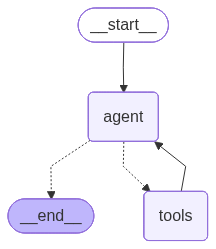

In [16]:
graph

In [17]:
from langchain_core.messages import HumanMessage

query = "What currency is in Billy Giles' birthplace?"

for chunk in graph.stream({"messages": [HumanMessage(query)]}, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

What currency is in Billy Giles' birthplace?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_E37eWkDGCDcwl6v0txrTFJol)
 Call ID: call_E37eWkDGCDcwl6v0txrTFJol
  Args:
    query: Billy Giles birthplace
================================= Tool Message =================================
Name: duckduckgo_search

Neil Aspinall · Geoff Emerick · Brian Epstein · Mal Evans · Allen Klein · George Martin · Giles Martin · Jimmie Nicol · Billy Preston · Tony ... Recent information on Billy Idol - his date of birth, where is he from and what nationality, instagram followers count, photos and astrological sign. Giles designed the dress for Cate Blanchett at the 2015 Cannes Film Festival which was also voted the best dress at the festival in 2015 and second ... However, Giles Deacon designed cloth for many celebrities like Pink, Cara Delevigne, Billy Po